In [4]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go
import time
from datetime import timedelta
import json
import os
import psutil
import gc
import math

# 强制进行垃圾回收（释放循环引用等未被引用的对象）
gc.collect()  
# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [5]:
############ customization
length = 24
width = 24
n1 = 9
n2 = 7
judge = 0

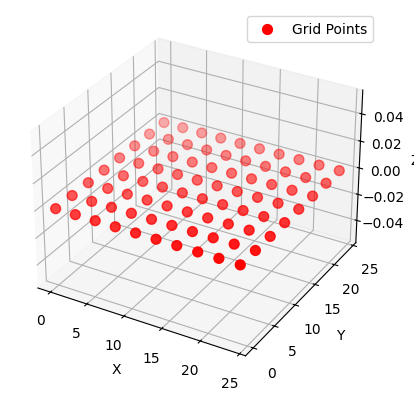

In [6]:
############### Problem context formulation

def generate_rectangular_grid_sg(length, width, n1, n2=2, judge=0, z=0, height=0):
    x_points = [i * (length / n1) for i in range(n1 + 1)]
    y_points = [j * (width / n2) for j in range(n2, -1, -1)]

    grid_points = []
    for x in x_points:
        for y in y_points:
            if y == width / 2:
                grid_points.append([x, y, height])
            else:
                grid_points.append([x, y, z])

    if judge == 1:
        corners = [
            [x_points[0], y_points[0], z],
            [x_points[0], y_points[-1], z],
            [x_points[-1], y_points[0], z],
            [x_points[-1], y_points[-1], z]
        ]
        grid_points = [point for point in grid_points if point not in corners]

    return grid_points

def plot_grid(grid_points, length, width):
    x = [point[0] for point in grid_points]
    y = [point[1] for point in grid_points]
    z = [point[2] for point in grid_points]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c='r', marker='o', s=50, label='Grid Points')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

def generate_connectivity_matrix(new_coords):
    indexed_points = {tuple(point): idx + 1 for idx, point in enumerate(new_coords)}
    connectivity = []

    x_values = sorted(set(point[0] for point in new_coords))
    for x in x_values:
        points_on_line = [point for point in new_coords if point[0] == x]
        points_on_line.sort(key=lambda p: p[1], reverse=True) 

        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    y_values = sorted(set(point[1] for point in new_coords))
    for y in y_values:
        points_on_line = [point for point in new_coords if point[1] == y]
        points_on_line.sort(key=lambda p: p[0])  

        for i in range(len(points_on_line) - 1):
            node1 = indexed_points[tuple(points_on_line[i])]
            node2 = indexed_points[tuple(points_on_line[i + 1])]
            connectivity.append([node1, node2])

    return connectivity

grid_points = generate_rectangular_grid_sg(length, width, n1, n2, judge)
connectivity = generate_connectivity_matrix(grid_points)
plot_grid(grid_points, length, width)


###########################################################################################################################################################
n_dof_per_node = 6  # Degrees of freedom per node
grid_points = torch.tensor(grid_points, device=device, dtype=torch.float32)
total_dof = n_dof_per_node * len(grid_points)

########## Surrounding fixed
x_max = grid_points[:, 0].max()
x_min = grid_points[:, 0].min()
y_max = grid_points[:, 1].max()
y_min = grid_points[:, 1].min()

Fixed_nodes = torch.where(
    (grid_points[:, 1] == y_max) |  # y = y_max
    (grid_points[:, 1] == y_min)    # y = y_min
)[0]

Fixed_nodes += 1
Free_nodes = []

n_elements = len(connectivity)
n_nodes = len(grid_points)

for i in range(1, n_nodes + 1):
    if i not in Fixed_nodes:
        Free_nodes.append(i)


####### BCs
fixed_dof = []
for node in Fixed_nodes:
    fixed_dof.extend([(node - 1) * 6 + i for i in range(6)])

##########################################################################################################################################################
##########################################################################################################################################################

In [7]:
############################################################# Force condition
def Force_mat(F_value, F_type, total_dof=total_dof, Free_nodes=Free_nodes, judge=0):
    
    F = torch.zeros(total_dof, dtype=torch.float32, device=device)
    
    if judge == 0:
        F_value = torch.tensor([F_value] * len(Free_nodes), device=device) * 1000 # The force value/direction
        F_type = [F_type] * len(Free_nodes)  # The force type
    else:
        F_value = torch.tensor(F_value) * 1000
        F_value = torch.tensor(F_type)
    
    for idx, i in enumerate(Free_nodes):
        F[6 * (i - 1) + F_type[idx]] = F_value[idx]  # unit: KN / KN*m
        
    return F, F_value

In [8]:

def Symmetry_shaper(grid_points, connectivity, free_nodes):
    
    connectivity = torch.tensor(connectivity, dtype=torch.long, device=device)
    free_nodes = torch.tensor(free_nodes, dtype=torch.long, device=device)
    
    result_indices_x = []  
    result_indices_y = []  
    prev_x_list = []  
    prev_y_list = []  
    
    for node in free_nodes:
        node_coord = grid_points[node - 1] 
        x = node_coord[0]

        if x in prev_x_list:
            x_index = prev_x_list.index(x)
        else:
            result_indices_x.append([])
            prev_x_list.append(x)
            x_index = len(prev_x_list) - 1
        
        mask = (connectivity == node).any(dim=1)
        candidate_indices = torch.where(mask)[0] # indexing connectivity
        
        for idx in candidate_indices:
            conn = connectivity[idx]
            coord1 = grid_points[conn[0] - 1]
            coord2 = grid_points[conn[1] - 1]

            if coord1[0] == coord2[0] and coord1[0] == x:
                result_indices_x[x_index].append(idx.item())  
    
    for node in free_nodes:
        node_coord = grid_points[node - 1]  
        y = node_coord[1]
        
        if y in prev_y_list:
            y_index = prev_y_list.index(y)
        else:
            result_indices_y.append([])
            prev_y_list.append(y)
            y_index = len(prev_y_list) - 1
        
        mask = (connectivity == node).any(dim=1)
        candidate_indices = torch.where(mask)[0]
           
        for idx in candidate_indices:
            conn = connectivity[idx]
            coord1 = grid_points[conn[0] - 1]
            coord2 = grid_points[conn[1] - 1]
            if coord1[1] == coord2[1] and coord1[1] == y:
                result_indices_y[y_index].append(idx.item()) 

    max_len_x = max(len(indices) for indices in result_indices_x) if result_indices_x else 0
    max_len_y = max(len(indices) for indices in result_indices_y) if result_indices_y else 0
    
    for indices in result_indices_x:
        indices += [-1] * (max_len_x - len(indices))
    for indices in result_indices_y:
        indices += [-1] * (max_len_y - len(indices))
    
    result_x = torch.tensor(result_indices_x, dtype=torch.long, device=device)
    result_y = torch.tensor(result_indices_y, dtype=torch.long, device=device)
    result_x = torch.unique(result_x, dim=1)
    result_y = torch.unique(result_y, dim=1)

    len_y = result_y.size(0)
    half_y = len_y // 2
    len_x = result_x.size(0)
    half_x = len_x // 2
    
    y_upper = result_y[:half_y]  
    y_lower = result_y[half_y:]
    y_lower = torch.flip(y_lower, dims=[0])
    x_upper = result_x[:half_x] 
    x_lower = result_x[half_x:]
    x_lower = torch.flip(x_lower, dims=[0])
    
    idx_Y = torch.cat((y_upper, y_lower), dim=1)
    idx_X = torch.cat((x_upper, x_lower), dim=1)

    return idx_X, idx_Y

In [9]:
def save_fdm(state_idx, grid_points, new_node_coords, 
            connectivity, Free_nodes, Fixed_nodes, force, SED,
            save_dir="results", max_states=6):
    """
    多状态组合图保存函数
    
    参数:
        state_idx: 状态序号 (0=初始, 1=第cut次, 2=第2*cut次...)
        max_states: 组合图中最多显示的状态数
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # 数据准备
    x_orig = grid_points[:, 0].cpu().detach().numpy()
    y_orig = grid_points[:, 1].cpu().detach().numpy()
    z_orig = grid_points[:, 2].cpu().detach().numpy()
    
    x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
    y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
    z_fdm = new_node_coords[:, 2].cpu().detach().numpy()
    
    # 计算当前高度
    current_height = max(z_fdm)
    
    # 初始化图形容器
    if not hasattr(save_fdm, 'fig'):
        save_fdm.fig = plt.figure(figsize=(24, 16))
        save_fdm.axes = [save_fdm.fig.add_subplot(2, 3, i+1, projection='3d') 
                       for i in range(max_states)]
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
        save_fdm.saved_states = 0
        save_fdm.max_z = 0  # 用于统一z轴尺度
    
    # 检查是否已存满
    if save_fdm.saved_states >= max_states:
        filename = os.path.join(save_dir, f"FDM_States_{max_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        delattr(save_fdm, 'fig')
        delattr(save_fdm, 'axes')
        delattr(save_fdm, 'saved_states')
        delattr(save_fdm, 'max_z')
        print(f"Saved full states to {filename}")
        return
    
    # 更新最大z值（用于统一坐标尺度）
    if current_height > save_fdm.max_z:
        save_fdm.max_z = current_height
    
    # 获取当前子图并清除旧内容
    ax = save_fdm.axes[save_fdm.saved_states]
    ax.clear()
    
    # ========== 可视化绘制 ==========
    # 1. 绘制原始网格（浅灰色虚线）
    for i, j in connectivity:
        ax.plot([x_orig[i-1], x_orig[j-1]],
                [y_orig[i-1], y_orig[j-1]],
                [z_orig[i-1], z_orig[j-1]], 
                ':', color='#CCCCCC', linewidth=0.8, alpha=0.7)
    
    # 2. 绘制当前状态网格
    color = '#1f77b4' if state_idx == 0 else '#ff7f0e'  # 初始蓝色，迭代橙色
    for i, j in connectivity:
        ax.plot([x_fdm[i-1], x_fdm[j-1]],
                [y_fdm[i-1], y_fdm[j-1]],
                [z_fdm[i-1], z_fdm[j-1]], 
                '-', color=color, linewidth=1.8, alpha=0.9)
    
    # 3. 标记固定节点（黑色实心圆）
    for node in Fixed_nodes:
        ax.scatter(x_fdm[node-1], y_fdm[node-1], z_fdm[node-1],
                  c='black', s=50, marker='o', alpha=0.8)
    
    # 4. 添加高度标注（替换原来的力值标注）
    ax.text(x=0.05, y=0.90, z=save_fdm.max_z*1.05,
           s=f"Height: {current_height:.2f}m\nSE: {SED:.8f} ", 
           transform=ax.transAxes, 
           fontsize=10,
           bbox=dict(facecolor='white', alpha=0.7))
    
    # ========== 子图装饰 ==========
    ax.set_xlabel('X (m)', fontsize=9)
    ax.set_ylabel('Y (m)', fontsize=9)
    ax.set_zlabel('Z (m)', fontsize=9)
    ax.set_title(f"State {state_idx}" if state_idx > 0 else "Initial State", 
                fontsize=11, pad=12)
    ax.set_zlim(0, save_fdm.max_z * 1.1)  # 统一z轴尺度
    ax.view_init(elev=35, azim=45)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # 更新状态计数器
    save_fdm.saved_states += 1
    
    # 如果是最后一个状态，立即保存
    if save_fdm.saved_states == max_states:
        filename = os.path.join(save_dir, f"FDM_States_{max_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        delattr(save_fdm, 'fig')
        delattr(save_fdm, 'axes')
        delattr(save_fdm, 'saved_states')
        delattr(save_fdm, 'max_z')
        print(f"Saved full states to {filename}")


def finalize_fdm(save_dir="results"):
    """确保最后未满的组合图也能保存"""
    if hasattr(save_fdm, 'fig') and save_fdm.saved_states > 0:
        filename = os.path.join(save_dir, 
                              f"FDM_States_{save_fdm.saved_states}.png")
        save_fdm.fig.savefig(filename, dpi=200, bbox_inches='tight')
        plt.close(save_fdm.fig)
        print(f"Saved partial states ({save_fdm.saved_states}/{len(save_fdm.axes)}) to {filename}")
        # 清理属性
        for attr in ['fig', 'axes', 'saved_states', 'max_z']:
            if hasattr(save_fdm, attr):
                delattr(save_fdm, attr)

In [10]:
####### FDM part 
C = torch.zeros(n_elements, n_nodes, dtype=torch.float32, device=device)
for n, (i, j) in enumerate(connectivity):
    C[n, i - 1] = 1
    C[n, j - 1] = -1
    
px= torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)
py = torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)
pz = torch.zeros(len(Free_nodes), 1, dtype=torch.float32, device=device)


fixed_idces = torch.tensor([node - 1 for node in Fixed_nodes], device=device)
free_node_indices = torch.tensor([node - 1 for node in Free_nodes], device=device)

CF = C[:, fixed_idces]
CN = C[:, free_node_indices]

def FDM(Q, F_value, CN=CN, CF=CF, px=px, py=py, pz=pz, 
        fixed_idces=fixed_idces, free_node_indices=free_node_indices,
        node_coords=grid_points):
    
    pz[:, 0] = F_value
        
    Dn = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CN))
    DF = torch.matmul(torch.transpose(CN, 0, 1), torch.matmul(Q, CF))
    
    
    xF = node_coords[fixed_idces, 0].unsqueeze(1)
    yF = node_coords[fixed_idces, 1].unsqueeze(1)
    zF = node_coords[fixed_idces, 2].unsqueeze(1)
    
    xN = torch.matmul(torch.inverse(Dn), (px - torch.matmul(DF, xF)))
    yN = torch.matmul(torch.inverse(Dn), (py - torch.matmul(DF, yF)))
    zN = torch.matmul(torch.inverse(Dn), (pz - torch.matmul(DF, zF)))
        
    
    new_node_coords = node_coords.clone()
    new_node_coords[free_node_indices, 0] = xN.squeeze()
    new_node_coords[free_node_indices, 1] = yN.squeeze()
    new_node_coords[free_node_indices, 2] = zN.squeeze()
    
    return new_node_coords

In [15]:
###### FE part
D_radius = 0.75
D_young_modulus = 10e9 
D_shear_modulus = 0.7e9 
D_poisson_ratio = 0.3
cross_section_angle_a = 0  
cross_section_angle_b = 0  
a_small_number = 1e-10

def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    # Ensure theta is a tensor
    theta = torch.tensor(theta, dtype=torch.float32, device=device) if not isinstance(theta, torch.Tensor) else theta

    v_rotated = v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))
    return v_rotated

class Beam:
    def __init__(self,R, node_coordinates, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates

        # Material and geometry
        self.radius = R
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio

        # Cross-sectional properties
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])  # Length of the beam
        self.Iy = (torch.pi * self.radius ** 4) / 4 
        self.Iz = self.Iy
        self.A = torch.pi * self.radius ** 2
        self.J = (torch.pi * self.radius ** 4) / 2

        # Stiffness components
        self.S_u = self.young_modulus * self.A / self.length
        self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        self.S_Tr = self.shear_modulus * self.J / self.length

        # Section rotations at the two ends
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        """Element stiffness matrix."""
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32, device=device)

        return K_element

    def System_Transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32, device=device)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T

    def nodal_transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        return lambda_matrix


def assemble_stiffness_matrix(beams, n_nodes, n_dof_per_node, connectivity):
    """Global stiffness matrix assembly."""
    total_dof = n_nodes * n_dof_per_node  # Total degrees of freedom
    K_global = torch.zeros((total_dof, total_dof), dtype=torch.float32, device=device)
    
    for idx, (i, j) in enumerate(connectivity):
        Matrix_T = beams[idx].System_Transform()  # Get transformation matrix
        K_element = torch.matmul(torch.transpose(Matrix_T, 0, 1),
                                 torch.matmul(beams[idx].get_element_stiffness_matrix(), Matrix_T))

        start_idx = (i - 1) * n_dof_per_node
        end_idx = (j - 1) * n_dof_per_node
        K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] += K_element[0:6, 0:6]
        K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] += K_element[6:12, 6:12]
        K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] += K_element[0:6, 6:12]
        K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] += K_element[6:12, 0:6]

    return K_global

def robust_solve(K_global, F, fixed_dof, max_attempts=3):
    
    attempts = 0
    while attempts < max_attempts:
        reg = 1e-6 * torch.eye(K_global.shape[0], device=K_global.device)
        reg[fixed_dof, fixed_dof] = 0  
        K_reg = K_global + reg
        
        try:
            displacements = torch.linalg.solve(
                K_reg.to(torch.float64), 
                F.to(torch.float64)
            )
            return displacements.to(K_global.dtype)
            
        except RuntimeError:
            diag = torch.diag(K_global)
            extreme_mask = (diag > 1e12) & (~torch.isin(torch.arange(len(diag)), torch.tensor(fixed_dof)))  
            K_reg[extreme_mask] = 0
            K_reg[:, extreme_mask] = 0
            K_reg[extreme_mask, extreme_mask] = 1e12  
            
            K_reg[fixed_dof, :] = 0
            K_reg[:, fixed_dof] = 0
            K_reg[fixed_dof, fixed_dof] = 1e10  
            
            try:
                displacements, info = torch.linalg.cg(
                    K_reg.to(torch.float64),
                    F.to(torch.float64),
                    maxiter=5000,
                    atol=1e-6
                )
                if info > 0:
                    raise RuntimeError("CG nah nah")
                return displacements.to(K_global.dtype)
                
            except:
                K_pinv = torch.linalg.pinv(K_reg)
                K_pinv[fixed_dof, :] = 0  
                displacements = K_pinv @ F
                print("警告：使用伪逆求解，精度可能降低")
                return displacements
                
        attempts += 1
    
    raise RuntimeError("无法求解线性系统")



def Strain_E(node_coords, connectivity, fixed_dof, F, D_radius=D_radius):
    # Element Assembly
    Beam_lens = []
    beams = []
    for idx, connection in enumerate(connectivity):
        node_1_coords = node_coords[connection[0] - 1]
        node_2_coords = node_coords[connection[1] - 1]
        length = torch.norm(node_2_coords[1] - node_1_coords[0]) 
        
        beam = Beam(R=D_radius, node_coordinates=torch.stack([node_1_coords, node_2_coords]),
                    young_modulus=D_young_modulus,
                    shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                    Beta_b=cross_section_angle_b)
        beams.append(beam)
        Beam_lens.append(beam.length)
            
    
    # Stiffness renewal
    K_global = assemble_stiffness_matrix(beams, n_nodes=len(node_coords), n_dof_per_node=6, connectivity=connectivity)
    K_global[fixed_dof, :] = 0
    K_global[:, fixed_dof] = 0
    K_global[fixed_dof, fixed_dof] = 1e10

    displacements = robust_solve(K_global, F, fixed_dof)

    # Compute strain energy
    strain_energy_list = []
    force_list = []
    ASE_list = []
    V_list = []
    Local_d = torch.zeros(len(connectivity), 12, dtype=torch.float32, device=device)
    for n, (i, j) in enumerate(connectivity):
        matrix_T = beams[n].System_Transform()
        Tep_displacements = torch.cat(
            [displacements[6 * (i - 1):6 * (i - 1) + 6], displacements[6 * (j - 1):6 * (j - 1) + 6]], dim=0)
        Local_d_n = torch.matmul(Tep_displacements, matrix_T.T)
        Local_d[n, :] = Local_d_n.clone()
        K_l = beams[n].get_element_stiffness_matrix()
        strain_energy_list.append(0.5 * torch.matmul(Local_d_n, torch.matmul(K_l, Local_d_n.reshape(-1, 1))))
        force_list.append(torch.matmul(K_l, Local_d_n.reshape(-1, 1)))
        ASE_list.append(0.5 * (Local_d_n[0]-Local_d_n[6]) * beams[n].S_u * (Local_d_n[0]-Local_d_n[6]))                                                                                                           
        V_list.append(beams[n].length * beams[n].A)
     
    
    Strain_energy = torch.stack(strain_energy_list)
    forces = torch.stack(force_list)
    ASE = torch.stack(ASE_list)
    lens = torch.stack(Beam_lens)
    V = torch.stack(V_list)
    SED = Strain_energy / V
    rf = torch.var(SED)
    
    return Strain_energy, forces, displacements, ASE, lens, rf, V

In [16]:
def optimizer(q, gradients, step):
    
    q.data -= gradients / torch.norm(gradients ) * step

    return q
    
def check_available_memory():
    """返回当前可用CPU内存（MB）"""
    return psutil.virtual_memory().available / (1024 ** 2)

In [17]:
############### Formulating :::::
####### Gradient descent
step = 0.05
epochs = 800
# Initilizing
patience = 20
count = 0
idx_X, idx_Y = Symmetry_shaper(grid_points, connectivity, Free_nodes)
####### Force Condition

_, F_value = Force_mat(- 1, 2)
F_fe_g, _ = Force_mat(-1, 2)

F_fe = F_fe_g

r = 1 / torch.max(F_value)

print('r', r)

r tensor(-0.0010)


In [18]:
############## Optimization loop

#### Initializing Data storage
os.makedirs("data_records", exist_ok=True)
optimization_data = {
    "metadata": {
        "project": "Structural Optimization",
        "Context": "FDM + FE{Gravity + X +Y}",
        "device": str(device),
        "parameters": {
            "length": length,
            "width": width,
            "grid_size": f"{n1}x{n2}",
            "epochs": epochs,
            "step_size": step
        }
    },
    "iterations": []
}

####### Loop start
n_elem = len(connectivity)
q = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0, 0.1, 0.1, 0.1], requires_grad=True, device=device)
start_time = time.time()
cut = epochs / 5
ES_his = []
LP_his = []
R_his = []
Ratio = []

# Loop start
for iteration in range(epochs + 1):
    print('ite', iteration)
    
    iter_start = time.time() 
    
    avail_mem = check_available_memory()
    print(f"Iter {iteration} - Available Memory: {avail_mem:.2f} MB")
    if avail_mem < 1000: 
        print(f"⚠️  Low memory warning: {avail_mem:.2f} MB left!")
    
    # Forwards
    q_vec = torch.zeros(n_elements, requires_grad=True, device=device).clone()
    for i in range(len(idx_X)):
        q_vec[idx_X[i,:]] = q[i] 
    for j in range(len(idx_Y)):
        q_vec[idx_Y[j,:]] = q[j+len(idx_X)] 
    q_vec = q_vec * 1 / r 
    Q = torch.diag(q_vec)   # scaling
    new_node_coords = FDM(Q, F_value)
    height = max(new_node_coords[:,2])
    
    
    ####### FDM time
    FDM_time = (time.time() - iter_start) / 60
        
    N_coords = new_node_coords.clone()
    FE_str = time.time()
    Strain_energy, forces, displacements, ASE, Beam_lens, R, V = Strain_E(N_coords, connectivity, fixed_dof, F_fe)
    
    ######## FE time
    FE_time = (time.time() - FE_str) / 60  
    force = abs(forces[:, 0, 0])
    load_path = torch.dot(abs(q_vec * Beam_lens) , Beam_lens)
    Total_ES = torch.sum(Strain_energy) 
    Axial_rate = torch.sum(ASE) / Total_ES
    Volume = torch.sum(V)
    

    
    # Loss_his.append(loss.item())
    R_his.append(R.clone().detach().item())
    LP_his.append(load_path.item()) 
    ES_his.append(Total_ES.item())
    Ratio.append(torch.sum(ASE) / Total_ES) 
    
    
    print('Ratio', torch.sum(ASE) / Total_ES)
    print("Estrain:", Total_ES)
    print('load_path', load_path)
    print("R:", R)
    print('ite height:', height)

    ############################ Deformation
    N_coords = N_coords.reshape(-1)
    New_Coordinates = torch.zeros(n_nodes * 3, dtype=torch.float32, device=device)
    for n in range(n_nodes):
        New_Coordinates[3*n : 3*n+3] = N_coords[3*n : 3*n+3] + displacements[6*n : 6*n+3]
    New_Coordinates = New_Coordinates.view(n_nodes, 3).clone()
        
    # Backwards
    
    Back_str = time.time()
    if q.grad is not None:
        q.grad.detach_()
        q.grad.zero_()
       
    load_path.backward(retain_graph=True)
    Back_time = (time.time() - Back_str) / 60
    
    # Grad
    gradients = q.grad
    frob_norm = torch.norm(gradients)
    q = optimizer(q, gradients, step)
    
    Wins_q = q.cpu().clone().detach()
    print('Wins_q', Wins_q)    
    print('Wins_grad', gradients) 
    
    with torch.no_grad():
        q[:5].clamp_(min=0.5, max=1.5)
        q[5:].clamp_(min=0.0, max=2.0)

    ####### Data storage:
    iteration_record = {
    "iteration": iteration,
    "variables": q.detach().cpu().numpy().tolist(),
    "strain_energy": Total_ES.item(),
    "Load_path": load_path.item(),
    "Axial SE ratio": Axial_rate.item(),
    "Volume": Volume .item(),
    "R": R.item(),
    "gradient_norm": torch.norm(gradients).item() if q.grad is not None else 0.0,
               "timing": {
            "FDM_time": FDM_time,
            "FE_time": FE_time,
            "Back_propagation time": Back_time,
        },
    }  
    optimization_data["iterations"].append(iteration_record)

    if iteration % cut == 0 or iteration == 0:
        state_idx = iteration // cut  
        save_fdm(state_idx, grid_points, new_node_coords, 
                connectivity, Free_nodes, Fixed_nodes, 
                force, Total_ES.detach().cpu().item())
    
    # print iteration
    if iteration % 5 == 0:
        print(f"Iteration {iteration}: Normalized Gradient = {frob_norm}, Adaptive learning rate = {step}")

    if iteration % 10 == 0:
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()
            
    ######## Early stopping
    if iteration > 0:  
        Pre_Total_ES = ES_his[iteration - 1]  
        change = abs(Total_ES - Pre_Total_ES) / Pre_Total_ES 
        if change < 1/100000:
            count += 1
        else:
            count = 0 
        if count >= patience:
            print(f"Early stopping at iteration {iteration}: Total_ES change < 1%% for {patience} consecutive iterations.")
            break 
            

finalize_fdm() 
total_time = (time.time() - iter_start) / 60
optimization_data["metadata"].update({
    "Ite_time": total_time,
})

with open(os.path.join("data_records", "FULL_data.json"), 'w') as f:
    json.dump(optimization_data, f, indent=2)
    
print("Optimization completed.")
print(q)
print("Estrain:", Total_ES)

ite 0
Iter 0 - Available Memory: 5144.96 MB


/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_47070/864091484.py:13: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Cross.cpp:67.)
  cross_product = torch.cross(k, v)


Ratio tensor(0.9645, grad_fn=<DivBackward0>)
Estrain: tensor(0.1222, grad_fn=<SumBackward0>)
load_path tensor(1138338.2500, grad_fn=<DotBackward0>)
R: tensor(3.6351e-08, grad_fn=<VarBackward0>)
ite height: tensor(6.0000, grad_fn=<UnbindBackward0>)
Wins_q tensor([0.9822, 0.9825, 0.9825, 0.9825, 0.9825, 0.0813, 0.0824, 0.0829])
Wins_grad tensor([110712.5000, 108724.2500, 108582.5234, 108572.3047, 108571.6250,
        116082.9453, 109366.8281, 106308.5703])
Iteration 0: Normalized Gradient = 310132.21875, Adaptive learning rate = 0.05
ite 1
Iter 1 - Available Memory: 5136.52 MB
Ratio tensor(0.9658, grad_fn=<DivBackward0>)
Estrain: tensor(0.1197, grad_fn=<SumBackward0>)
load_path tensor(1122869.2500, grad_fn=<DotBackward0>)
R: tensor(3.4432e-08, grad_fn=<VarBackward0>)
ite height: tensor(6.1085, grad_fn=<UnbindBackward0>)
Wins_q tensor([0.9646, 0.9652, 0.9652, 0.9652, 0.9652, 0.0622, 0.0643, 0.0652])
Wins_grad tensor([108140.9219, 106642.6953, 106561.4375, 106558.0000, 106558.1250,
       

Ratio tensor(0.9821, grad_fn=<DivBackward0>)
Estrain: tensor(0.0904, grad_fn=<SumBackward0>)
load_path tensor(981244.1250, grad_fn=<DotBackward0>)
R: tensor(2.0925e-08, grad_fn=<VarBackward0>)
ite height: tensor(8.3423, grad_fn=<UnbindBackward0>)
Wins_q tensor([6.9691e-01, 6.9735e-01, 6.9737e-01, 6.9737e-01, 6.9737e-01, 7.5569e-09,
        5.7432e-08, 4.8364e-08])
Wins_grad tensor([ 5.6314e+04,  5.6464e+04,  5.6471e+04,  5.6471e+04,  5.6471e+04,
        -1.9073e-02, -1.4496e-01, -1.2207e-01])
ite 17
Iter 17 - Available Memory: 5055.15 MB
Ratio tensor(0.9833, grad_fn=<DivBackward0>)
Estrain: tensor(0.0885, grad_fn=<SumBackward0>)
load_path tensor(975321.7500, grad_fn=<DotBackward0>)
R: tensor(2.0500e-08, grad_fn=<VarBackward0>)
ite height: tensor(8.6094, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 0.6870,  0.6874,  0.6874,  0.6874,  0.6874, -0.0258, -0.0258, -0.0258])
Wins_grad tensor([ 49271.0234,  49416.6250,  49423.5391,  49423.5859,  49423.5859,
        127999.9766, 127999.9062, 1279

Ratio tensor(0.9891, grad_fn=<DivBackward0>)
Estrain: tensor(0.0809, grad_fn=<SumBackward0>)
load_path tensor(960058.7500, grad_fn=<DotBackward0>)
R: tensor(1.9389e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.4002, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.9921e-01,  5.9929e-01,  5.9930e-01,  5.9930e-01,  5.9930e-01,
        -3.2447e-07, -8.3435e-07, -9.2706e-08])
Wins_grad tensor([-3.6648e+03, -3.6837e+03, -3.6844e+03, -3.6846e+03, -3.6846e+03,
         5.3406e-02,  1.3733e-01,  1.5259e-02])
ite 32
Iter 32 - Available Memory: 5052.16 MB
Ratio tensor(0.9881, grad_fn=<DivBackward0>)
Estrain: tensor(0.0820, grad_fn=<SumBackward0>)
load_path tensor(960349.1250, grad_fn=<DotBackward0>)
R: tensor(1.9434e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.0132, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.7694e-01,  5.7691e-01,  5.7691e-01,  5.7691e-01,  5.7691e-01,
         7.8970e-08,  1.1845e-07, -1.1845e-07])
Wins_grad tensor([ 8.6055e+03,  8.6487e+03,  8.6504e+03,  8.6507e+03,  

...

Ratio tensor(0.9882, grad_fn=<DivBackward0>)
Estrain: tensor(0.0819, grad_fn=<SumBackward0>)
load_path tensor(960286.7500, grad_fn=<DotBackward0>)
R: tensor(1.9428e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.0412, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.9541e-01,  5.9565e-01,  5.9566e-01,  5.9563e-01,  5.9566e-01,
        -3.5190e-02, -3.5189e-02,  3.3560e-08])
Wins_grad tensor([ 7.7328e+03,  7.8791e+03,  7.8828e+03,  7.8633e+03,  7.8812e+03,
         1.2800e+05,  1.2800e+05, -1.2207e-01])
ite 737
Iter 737 - Available Memory: 4465.63 MB
Ratio tensor(0.9883, grad_fn=<DivBackward0>)
Estrain: tensor(0.0818, grad_fn=<SumBackward0>)
load_path tensor(960207.7500, grad_fn=<DotBackward0>)
R: tensor(1.9421e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.0770, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.9285e-01,  5.9304e-01,  5.9304e-01,  5.9302e-01,  5.9304e-01,
         3.8480e-08,  8.8799e-08, -4.9660e-02])
Wins_grad tensor([ 6.6105e+03,  6.7375e+03,  6.7406e+03,  6.7239e+03,

ite 751
Iter 751 - Available Memory: 4587.43 MB
Ratio tensor(0.9884, grad_fn=<DivBackward0>)
Estrain: tensor(0.0817, grad_fn=<SumBackward0>)
load_path tensor(960144.5000, grad_fn=<DotBackward0>)
R: tensor(1.9415e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.1115, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.9186e-01,  5.9203e-01,  5.9203e-01,  5.9201e-01,  5.9203e-01,
         9.4603e-09, -3.5271e-02, -3.5271e-02])
Wins_grad tensor([ 5.5270e+03,  5.6336e+03,  5.6360e+03,  5.6226e+03,  5.6352e+03,
        -3.4332e-02,  1.2800e+05,  1.2800e+05])
ite 752
Iter 752 - Available Memory: 4562.80 MB
Ratio tensor(0.9884, grad_fn=<DivBackward0>)
Estrain: tensor(0.0816, grad_fn=<SumBackward0>)
load_path tensor(960104.1875, grad_fn=<DotBackward0>)
R: tensor(1.9410e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.1375, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.9003e-01,  5.9016e-01,  5.9016e-01,  5.9015e-01,  5.9016e-01,
        -4.9827e-02,  4.7518e-08,  5.9398e-09])
Wins_grad tensor([ 4.

Ratio tensor(0.9893, grad_fn=<DivBackward0>)
Estrain: tensor(0.0807, grad_fn=<SumBackward0>)
load_path tensor(960185.0625, grad_fn=<DotBackward0>)
R: tensor(1.9390e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.4906, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.7394e-01,  5.7377e-01,  5.7376e-01,  5.7378e-01,  5.7376e-01,
        -3.5238e-02, -1.2602e-08, -3.5238e-02])
Wins_grad tensor([-6.4924e+03, -6.6182e+03, -6.6222e+03, -6.6064e+03, -6.6207e+03,
         1.2800e+05,  4.5776e-02,  1.2800e+05])
ite 767
Iter 767 - Available Memory: 4594.39 MB
Ratio tensor(0.9893, grad_fn=<DivBackward0>)
Estrain: tensor(0.0808, grad_fn=<SumBackward0>)
load_path tensor(960130.3125, grad_fn=<DotBackward0>)
R: tensor(1.9389e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.4573, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.9597e-01,  5.9622e-01,  5.9623e-01,  5.9619e-01,  5.9622e-01,
        -9.2863e-08,  1.8573e-07,  2.4763e-07])
Wins_grad tensor([-5.4283e+03, -5.5329e+03, -5.5364e+03, -5.5230e+03,

ite 781
Iter 781 - Available Memory: 4830.58 MB
Ratio tensor(0.9893, grad_fn=<DivBackward0>)
Estrain: tensor(0.0807, grad_fn=<SumBackward0>)
load_path tensor(960152.3125, grad_fn=<DotBackward0>)
R: tensor(1.9390e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.4716, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.7480e-01,  5.7464e-01,  5.7463e-01,  5.7465e-01,  5.7464e-01,
         1.1559e-08, -3.5259e-02, -3.5259e-02])
Wins_grad tensor([-5.8807e+03, -5.9972e+03, -6.0013e+03, -5.9862e+03, -5.9985e+03,
        -4.1962e-02,  1.2800e+05,  1.2800e+05])
ite 782
Iter 782 - Available Memory: 4591.06 MB
Ratio tensor(0.9892, grad_fn=<DivBackward0>)
Estrain: tensor(0.0808, grad_fn=<SumBackward0>)
load_path tensor(960107.4375, grad_fn=<DotBackward0>)
R: tensor(1.9389e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.4415, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.7672e-01,  5.7659e-01,  5.7659e-01,  5.7660e-01,  5.7659e-01,
        -4.9810e-02,  1.0094e-07,  6.5317e-08])
Wins_grad tensor([-4.

Ratio tensor(0.9891, grad_fn=<DivBackward0>)
Estrain: tensor(0.0809, grad_fn=<SumBackward0>)
load_path tensor(960068.1875, grad_fn=<DotBackward0>)
R: tensor(1.9389e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.4097, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.7760e-01,  5.7749e-01,  5.7749e-01,  5.7750e-01,  5.7749e-01,
        -3.5313e-02, -3.5313e-02,  3.3677e-08])
Wins_grad tensor([-3.9112e+03, -3.9877e+03, -3.9900e+03, -3.9794e+03, -3.9882e+03,
         1.2800e+05,  1.2800e+05, -1.2207e-01])
ite 797
Iter 797 - Available Memory: 4426.90 MB
Ratio tensor(0.9891, grad_fn=<DivBackward0>)
Estrain: tensor(0.0809, grad_fn=<SumBackward0>)
load_path tensor(960047.9375, grad_fn=<DotBackward0>)
R: tensor(1.9389e-08, grad_fn=<VarBackward0>)
ite height: tensor(10.3898, grad_fn=<UnbindBackward0>)
Wins_q tensor([ 5.7888e-01,  5.7880e-01,  5.7879e-01,  5.7881e-01,  5.7880e-01,
        -1.1901e-08, -1.1901e-08, -4.9915e-02])
Wins_grad tensor([-3.2821e+03, -3.3458e+03, -3.3478e+03, -3.3388e+03,

In [23]:
# fig, ax1 = plt.subplots(figsize=(10, 6))

# color = 'red'
# ax1.set_ylabel('LOss', color=color)
# ax1.plot(range(len(LS_his)), LS_his, label='LOss', color=color, linewidth=2, linestyle='--')
# ax1.tick_params(axis='y', labelcolor=color)

# # Mark specific points
# marker_points = [
#     0,  # First point
#     *range(50, len(LS_his), 50),  # Every 200th point
#     len(LS_his)-1  # Last point
# ]

# for point in marker_points:
#     ax1.scatter(point, LS_his[point], color='blue', zorder=5)
#     ax1.text(point, LS_his[point]* 1.02, 
#              f'({LS_his[point]:.4f})',
#              ha='right' if point == len(ES_his)-1 else 'left',
#              va='bottom',
#              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# ax1.legend(loc='upper right')
# plt.title('Loss vs. Iterations')
# plt.tight_layout()
# plt.savefig('LS_history.png', dpi=150, bbox_inches='tight')
# plt.show()

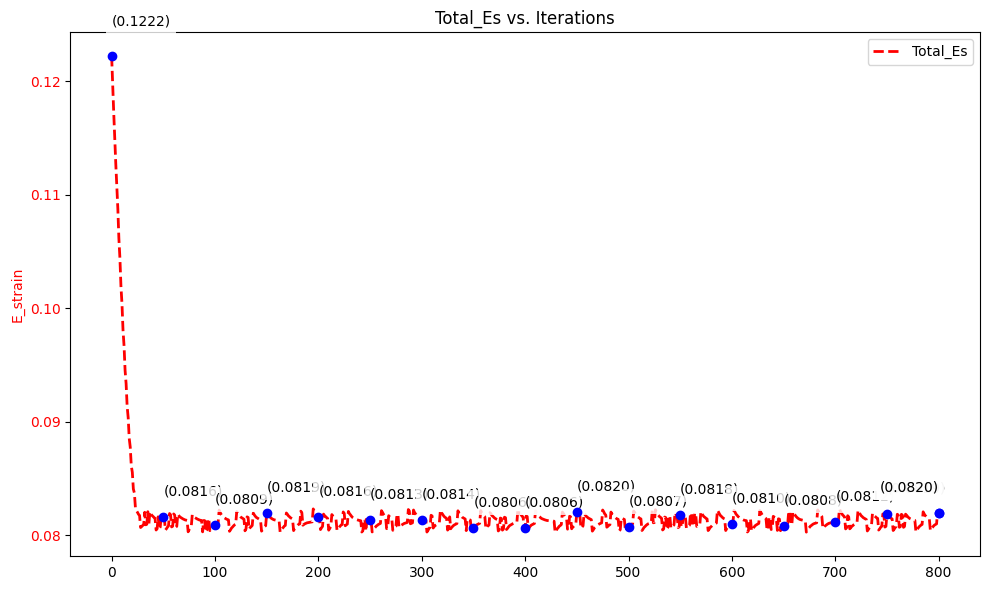

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'red'
ax1.set_ylabel('E_strain', color=color)
ax1.plot(range(len(ES_his)), ES_his, label='Total_Es', color=color, linewidth=2, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Mark specific points
marker_points = [
    0,  # First point
    *range(50, len(ES_his), 50),  # Every 200th point
    len(ES_his)-1  # Last point
]

for point in marker_points:
    ax1.scatter(point, ES_his[point], color='blue', zorder=5)
    ax1.text(point, ES_his[point]* 1.02, 
             f'({ES_his[point]:.4f})',
             ha='right' if point == len(ES_his)-1 else 'left',
             va='bottom',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')
plt.title('Total_Es vs. Iterations')
plt.tight_layout()
plt.savefig('Es_history.png', dpi=150, bbox_inches='tight')
plt.show()

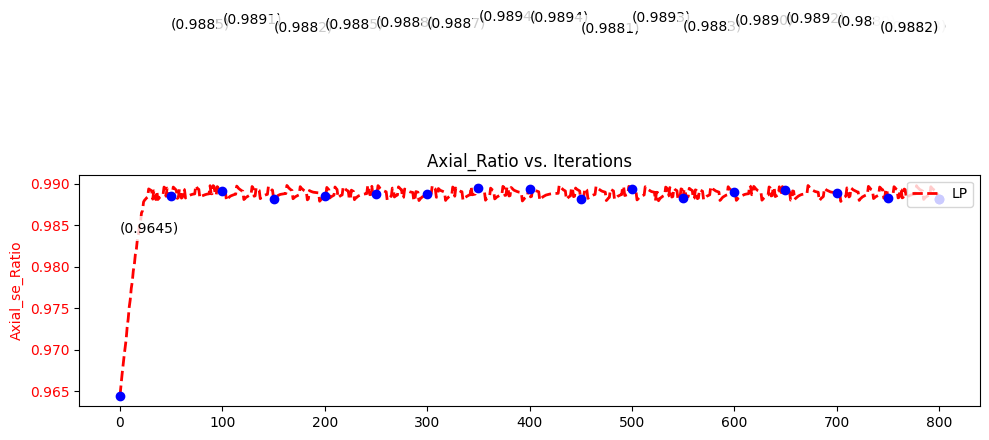

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 6))
Ratio = torch.tensor(Ratio)


color = 'red'
ax1.set_ylabel('Axial_se_Ratio', color=color)
ax1.plot(range(len(Ratio)), Ratio.cpu().numpy(), label='LP', color=color, linewidth=2, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Mark specific points
marker_points = [
    0,  # First point
    *range(50, len(Ratio), 50),  # Every 200th point
    len(Ratio)-1  # Last point
]

for point in marker_points:
    ax1.scatter(point, Ratio[point], color='blue', zorder=5)
    ax1.text(point, Ratio[point]* 1.02, 
             f'({Ratio[point]:.4f})',
             ha='right' if point == len(Ratio)-1 else 'left',
             va='bottom',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')
plt.title('Axial_Ratio vs. Iterations')
plt.tight_layout()
plt.savefig('Axial_ratio_history.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_47070/3105733870.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Ratio = torch.tensor(Ratio)


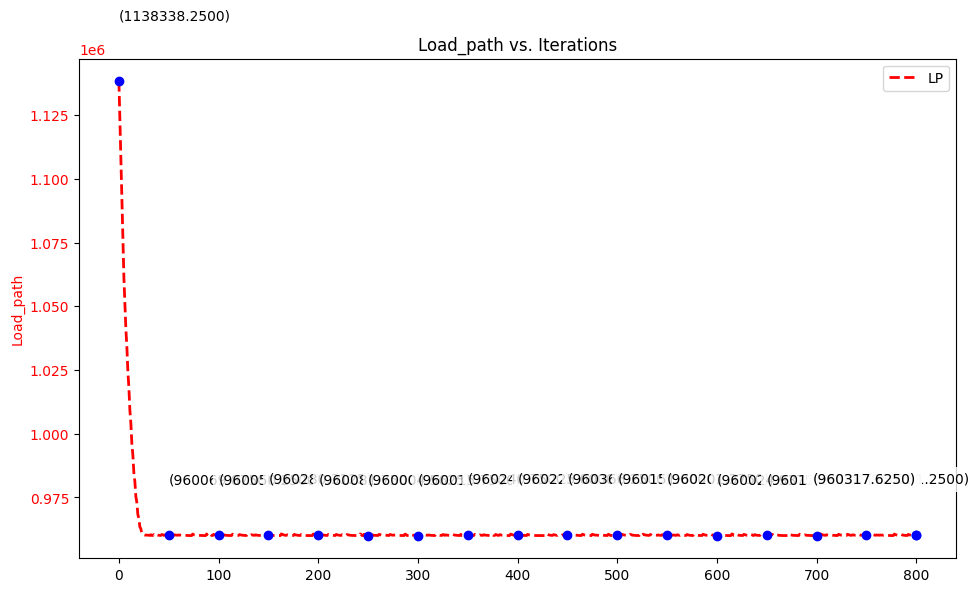

In [21]:
fig, ax1 = plt.subplots(figsize=(10, 6))
Ratio = torch.tensor(Ratio)
LP_his = torch.tensor(LP_his)

color = 'red'
ax1.set_ylabel('Load_path', color=color)
ax1.plot(range(len(LP_his)), LP_his.cpu().numpy(), label='LP', color=color, linewidth=2, linestyle='--')
ax1.tick_params(axis='y', labelcolor=color)

# Mark specific points
marker_points = [
    0,  # First point
    *range(50, len(LP_his), 50),  
    len(LP_his)-1  # Last point
]

for point in marker_points:
    ax1.scatter(point, LP_his[point], color='blue', zorder=5)
    ax1.text(point, LP_his[point]* 1.02, 
             f'({LP_his[point]:.4f})',
             ha='right' if point == len(Ratio)-1 else 'left',
             va='bottom',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax1.legend(loc='upper right')
plt.title('Load_path vs. Iterations')
plt.tight_layout()
plt.savefig('Load_path_his.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
########################

In [ ]:
#######################

In [24]:
##### Visual
#############################################################################################################
## Visualization 1
x_orig = grid_points[:, 0].cpu().detach().numpy()
y_orig = grid_points[:, 1].cpu().detach().numpy()
z_orig = grid_points[:, 2].cpu().detach().numpy()

x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
z_fdm = new_node_coords[:, 2].cpu().detach().numpy()

Max_height = max(z_fdm)
fig = go.Figure()


for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=1),
        name='Grid',
        showlegend=False
    ))

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[i-1], x_fdm[j-1]],
        y=[y_fdm[i-1], y_fdm[j-1]],
        z=[z_fdm[i-1], z_fdm[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FDM solution',
        showlegend=False
    ))


for node in Fixed_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='black'),
        name=f'Fixed Node {node}',
        showlegend=False
    ))
    

force_traces = []
force_np = force.cpu().detach().numpy() 
for idx, connection in enumerate(connectivity):
    i, j = connection
    mid_x = (x_fdm[i-1] + x_fdm[j-1]) / 2
    mid_y = (y_fdm[i-1] + y_fdm[j-1]) / 2
    mid_z = (z_fdm[i-1] + z_fdm[j-1]) / 2
    trace = go.Scatter3d(
        x=[mid_x],
        y=[mid_y],
        z=[mid_z],
        mode='markers+text',
        marker=dict(size=1, color='green'),
        text=[f"{force_np[idx]:.0f}"],
        textposition='top center',
        textfont=dict(size=8),
        name=f'Force {idx+1}',
        visible=True
    )
    force_traces.append(trace)
    fig.add_trace(trace)

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.1,
            y=1.1,
            buttons=[
                dict(
                    label="✅ Show forces",
                    method="update",
                    args=[{"visible": [True] * len(fig.data)}],
                ),
                dict(
                    label="❌ Hide forces",
                    method="update",
                    args=[{"visible": [True] * (len(fig.data) - len(force_traces)) + [False] * len(force_traces)}],
                )
            ]
        )
    ],
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        aspectmode='data'
    ),
    title='OPT',
    annotations=[
        dict(
            x=0.05,  # X position (0-1, left to right)
            y=0.95,  # Y position (0-1, bottom to top)
            xref="paper",
            yref="paper",
            text=f"Strain energy= {Total_ES:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, Load_path  = {load_path_q :.4f} ",
            showarrow=False,
            font=dict(
                size=14,
                color="black"
            ),
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            borderpad=4
        )
    ]
)
fig.show()

fig.write_html("E_strain Opt(Z).html")

print(f"Strain energy= {Total_ES:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, Load_path  = {load_path :.4f} ")


Strain energy= 0.0820, Volume = 918.5100, Max_height = 10.0283, Load_path  = 960317.6250 


In [27]:
######## Fe_test
####### Set FE context
F_test = torch.zeros(total_dof, dtype=torch.float32, device=device)
f_test = [1] * len(Free_nodes)  # The force type
F_vatest = torch.tensor([1] * len(Free_nodes), device=device) * 1000 # The force value/direction

for idx, i in enumerate(Free_nodes):
    F_test[6 * (i - 1) + f_test [idx]] = F_vatest [idx]  # unit: KN / KN*m
    
q_test = q.cpu().clone().detach()
q_vec_t = torch.zeros(n_elements, requires_grad=True, device=device).clone()
for i in range(len(idx_X)):
    q_vec_t[idx_X[i,:]] = q_test[i] 
for j in range(len(idx_Y)):
    q_vec_t[idx_Y[j,:]] = q_test[j+len(idx_X)]  
Q_t = torch.diag(q_vec_t) * 1 / r  # scaling

new_node_coords_t = FDM(Q_t, F_value) 

Test_coords = new_node_coords_t.clone()
Strain_energy_test, forces_test, _, _, Beam_lens, _, _ = Strain_E(Test_coords, connectivity, fixed_dof, F_test)

force_t = forces_test[:, 0, 0]
load_path_t = torch.dot(force_t , Beam_lens)
print('load_path', load_path_t)

Total_ES_t = torch.sum(Strain_energy_test)
print(Total_ES_t)

SED = Total_ES_t / Volume


x_orig = grid_points[:, 0].cpu().detach().numpy()
y_orig = grid_points[:, 1].cpu().detach().numpy()
z_orig = grid_points[:, 2].cpu().detach().numpy()

x_fdm = Test_coords[:, 0].cpu().detach().numpy()
y_fdm = Test_coords[:, 1].cpu().detach().numpy()
z_fdm = Test_coords[:, 2].cpu().detach().numpy()

fig = go.Figure()

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=1),
        name='Grid',
        showlegend=False
    ))

for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[i-1], x_fdm[j-1]],
        y=[y_fdm[i-1], y_fdm[j-1]],
        z=[z_fdm[i-1], z_fdm[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='FDM solution',
        showlegend=False
    ))


for node in Fixed_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='black'),
        name=f'Fixed Node {node}',
        showlegend=False
    ))
    

force_traces = []
force_np = force_t.cpu().detach().numpy() 
for idx, connection in enumerate(connectivity):
    i, j = connection
    mid_x = (x_fdm[i-1] + x_fdm[j-1]) / 2
    mid_y = (y_fdm[i-1] + y_fdm[j-1]) / 2
    mid_z = (z_fdm[i-1] + z_fdm[j-1]) / 2
    trace = go.Scatter3d(
        x=[mid_x],
        y=[mid_y],
        z=[mid_z],
        mode='markers+text',
        marker=dict(size=1, color='green'),
        text=[f"{force_np[idx]:.0f}"],
        textposition='top center',
        textfont=dict(size=8),
        name=f'Force {idx+1}',
        visible=True
    )
    force_traces.append(trace)
    fig.add_trace(trace)

fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            direction="right",
            x=0.1,
            y=1.1,
            buttons=[
                dict(
                    label="✅ Show forces",
                    method="update",
                    args=[{"visible": [True] * len(fig.data)}],
                ),
                dict(
                    label="❌ Hide forces",
                    method="update",
                    args=[{"visible": [True] * (len(fig.data) - len(force_traces)) + [False] * len(force_traces)}],
                )
            ]
        )
    ],
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        aspectmode='data'
    ),
    title='Test with lateral load (Y)',
    # title='Test with gravity load',
    annotations=[
        dict(
            x=0.05,  # X position (0-1, left to right)
            y=0.95,  # Y position (0-1, bottom to top)
            xref="paper",
            yref="paper",
            text=f"Strain energy = {Total_ES_t:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, , Load_path  = {load_path_t :.4f}",
            showarrow=False,
            font=dict(
                size=14,
                color="black"
            ),
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            borderpad=4
        )
    ]
)

fig.show()
fig.write_html("E_strain Test(Y).html")
print(f"Strain energy= {Total_ES_t:.4f}, Volume = {Volume:.4f}, Max_height = {Max_height:.4f}, Load_path  = {load_path_t :.4f} ")


load_path tensor(111596.7188, grad_fn=<DotBackward0>)
tensor(1.2266, grad_fn=<SumBackward0>)


Strain energy= 1.2266, Volume = 918.5100, Max_height = 10.0283, Load_path  = 111596.7188 


In [ ]:
#############################################################################################################
## Visualization 2
x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
z_fdm = new_node_coords[:, 2].cpu().detach().numpy()

x_def = New_Coordinates[:, 0].cpu().detach().numpy()
y_def = New_Coordinates[:, 1].cpu().detach().numpy()
z_def = New_Coordinates[:, 2].cpu().detach().numpy()

fig = go.Figure()


for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[i-1], x_fdm[j-1]],
        y=[y_fdm[i-1], y_fdm[j-1]],
        z=[z_fdm[i-1], z_fdm[j-1]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Original Geometry'
    ))


for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_def[i-1], x_def[j-1]],
        y=[y_def[i-1], y_def[j-1]],
        z=[z_def[i-1], z_def[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='Deformed Geometry'
    ))


for node in Fixed_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='black'),
#         text=[f'Node {node}'],
        textposition='top center',
        name=f'Fixed Node {node}'
    ))    


fig.update_layout(
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        aspectmode='data'
    ),
    title='Deformation Comparison: Original vs. Deformed Geometry (FE Analysis)',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

fig.write_html("Deformation.html")

In [ ]:
## Visualization 3

q_ = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0, 0.1, 0.1, 0.1], requires_grad=True, device=device)
q_vec = torch.zeros(n_elements, requires_grad=True, device=device).clone()
for i in range(len(idx_X)):
    q_vec[idx_X[i,:]] = q_[i] 
for j in range(len(idx_Y)):
    q_vec[idx_Y[j,:]] = q_[j+len(idx_X)]  
Q = torch.diag(q_vec) * 1 / r  # scaling
new_node_coords = FDM(Q, F_value) 

x_orig = grid_points[:, 0].cpu().detach().numpy()
y_orig = grid_points[:, 1].cpu().detach().numpy()
z_orig = grid_points[:, 2].cpu().detach().numpy()

x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
z_fdm = new_node_coords[:, 2].cpu().detach().numpy()


fig = go.Figure()


for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_orig[i-1], x_orig[j-1]],
        y=[y_orig[i-1], y_orig[j-1]],
        z=[z_orig[i-1], z_orig[j-1]],
        mode='lines',
        line=dict(color='blue', width=1),
        name='Grid',
        showlegend=False
    ))


for connection in connectivity:
    i, j = connection
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[i-1], x_fdm[j-1]],
        y=[y_fdm[i-1], y_fdm[j-1]],
        z=[z_fdm[i-1], z_fdm[j-1]],
        mode='lines',
        line=dict(color='red', width=4),
        name='Initial Geometry',
        showlegend=False
    ))


for node in Free_nodes:
    
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1], x_fdm[node-1]],  
        y=[y_fdm[node-1], y_fdm[node-1]],  
        z=[z_fdm[node-1], z_fdm[node-1] - 2.0], 
        mode='lines',
        line=dict(color='green', width=3),
        showlegend=False,
        hoverinfo='none'
    ))
    
    fig.add_trace(go.Cone(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1] - 2.0],  
        u=[0], v=[0], w=[-0.5], 
        sizemode='scaled',
        sizeref=0.9,
        colorscale=[[0, 'green'], [1, 'green']],
        showscale=False
    ))



for node in Fixed_nodes:
    fig.add_trace(go.Scatter3d(
        x=[x_fdm[node-1]],
        y=[y_fdm[node-1]],
        z=[z_fdm[node-1]],
        mode='markers+text',
        marker=dict(size=5, color='black'),
#         text=[f'Node {node}'],
        textposition='top center',
        name=f'Fixed Node {node}',
        showlegend=False
    ))    

fig.update_layout(
    scene=dict(
        xaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        yaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        zaxis=dict(
            showbackground=False,
            showgrid=False,
            showline=False,
            showticklabels=False,
            title=''
        ),
        aspectmode='data'
    ),
    title='Initialization for FE solver',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    annotations=[
        dict(
            x=0.05,
            y=0.95,
            xref="paper",
            yref="paper",
            text=f"Load: Gravity {20} KN\n",
            showarrow=False,
            font=dict(size=14, color="black"),
            bgcolor="white",
            bordercolor="black",
            borderwidth=1,
            borderpad=4
        )
    ]
)

fig.show()

fig.write_html("Problem context.html")

In [ ]:
# def save_FE(iteration, new_node_coords, New_Coordinates, 
#                       connectivity, Free_nodes, Fixed_nodes, force, save_dir="visualizations"):
    
#     os.makedirs(save_dir, exist_ok=True)

#     x_fdm = new_node_coords[:, 0].cpu().detach().numpy()
#     y_fdm = new_node_coords[:, 1].cpu().detach().numpy()
#     z_fdm = new_node_coords[:, 2].cpu().detach().numpy()

#     x_def = New_Coordinates[:, 0].cpu().detach().numpy()
#     y_def = New_Coordinates[:, 1].cpu().detach().numpy()
#     z_def = New_Coordinates[:, 2].cpu().detach().numpy()


#     fig = go.Figure()

#     for connection in connectivity:
#         i, j = connection
#         fig.add_trace(go.Scatter3d(
#             x=[x_fdm[i-1], x_fdm[j-1]],
#             y=[y_fdm[i-1], y_fdm[j-1]],
#             z=[z_fdm[i-1], z_fdm[j-1]],
#             mode='lines',
#             line=dict(color='blue', width=4),
#             name='Original Geometry'
#         ))
    
    
#     for connection in connectivity:
#         i, j = connection
#         fig.add_trace(go.Scatter3d(
#             x=[x_def[i-1], x_def[j-1]],
#             y=[y_def[i-1], y_def[j-1]],
#             z=[z_def[i-1], z_def[j-1]],
#             mode='lines',
#             line=dict(color='red', width=4),
#             name='Deformed Geometry'
#         ))
    
    
    
#     for node in Fixed_nodes:
#         fig.add_trace(go.Scatter3d(
#             x=[x_fdm[node-1]],
#             y=[y_fdm[node-1]],
#             z=[z_fdm[node-1]],
#             mode='markers+text',
#             marker=dict(size=5, color='black'),
#     #         text=[f'Node {node}'],
#             textposition='top center',
#             name=f'Fixed Node {node}'
#         )) 

    
#     fig.update_layout(
#         scene=dict(
#             xaxis_title='X',
#             yaxis_title='Y',
#             zaxis_title='Z',
#             aspectmode='data'
#         ),
#         title='Deformed Geometry (FE Analysis)',
#         legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
#     )

#     filename = os.path.join(save_dir, f"Deformation_iter_{iteration}.html")
#     fig.write_html(filename)
#     print(f"Saved deformation to {filename}")